<a href="https://colab.research.google.com/github/Rique-Nunes/4UBD-Desempenho-Escolar-e-Desigualdade/blob/main/Prova4UBDAV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ETL (01_ETL.IPYNB)**

In [1]:
import pandas as pd
import geopandas as gpd

print("Carregando e reprojetando o mapa de Minas Gerais")
url_malha = "https://raw.githubusercontent.com/tbrugz/geodata-br/master/geojson/geojs-31-mun.json"

# Lendo o arquivo direto da internet
mg_municipios = gpd.read_file(url_malha)

# Reprojetando para o sistema métrico oficial
mg_municipios = mg_municipios.to_crs(epsg=31983)

# Salvando a malha pura na pasta de dados
mg_municipios.to_file('dados/municipios-mg.geojson', driver='GeoJSON')
print("Arquivo salvo, exibe duas linhas: ")

display(mg_municipios.head(2))

Carregando e reprojetando o mapa de Minas Gerais
Arquivo salvo, exibe duas linhas: 


,id,name,description,geometry
0,3100104,Abadia dos Dourados,Abadia dos Dourados,"POLYGON ((241429.802 7990562.876, 242359.697 7..."
1,3100203,Abaeté,Abaeté,"POLYGON ((480831.209 7911603.048, 481764.623 7..."


In [2]:
print("Carregando dados do PIB Per Capita Municipal")

# Lendo  com separador por vírgula e pulando as 4 linhas iniciais
df_pib = pd.read_csv('dados/pib_rendapercapitanova.csv',
                     sep=',',
                     skiprows=4,
                     header=None,
                     encoding='utf-8')

# Renomeando as colunas
df_pib.columns = ['nome_municipio', 'ano', 'pib_total']

# Limpeza dos números: remove o ponto de milhar e altera a vírgula para o ponto decimal
df_pib['pib_total'] = df_pib['pib_total'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df_pib['pib_total'] = pd.to_numeric(df_pib['pib_total'], errors='coerce')

# Remove espaços em branco invisíveis nas extremidades dos nomes das cidades
df_pib['nome_municipio'] = df_pib['nome_municipio'].astype(str).str.strip()

print("Mostrando 3 linhas de dados")
display(df_pib.head(3))

Carregando dados do PIB Per Capita Municipal
Mostrando 3 linhas de dados


,nome_municipio,ano,pib_total
0,Abadia dos Dourados,2021.0,25174.26
1,Abaeté,2021.0,23266.10
2,Abre Campo,2021.0,19553.86


In [3]:
# tratando a panilha do INEP
print("Dados de Educação do INEP")

df_ideb = pd.read_csv('dados/ideb_mg_anos_iniciais.csv', sep=';', encoding='utf-8')

# Filtrando apenas a Rede Pública
df_publica = df_ideb[df_ideb['Rede'] == 'Pública'].copy()

# Tratando a coluna de notas trocando vírgula por ponto
coluna_nota_original = 'IDEB\n2023\n(N x P)'
df_publica['nota_ideb_2023'] = df_publica[coluna_nota_original].astype(str).str.replace(',', '.')
df_publica['nota_ideb_2023'] = pd.to_numeric(df_publica['nota_ideb_2023'], errors='coerce')

# Mantendo apenas as colunas que importam para não pesar o arquivo
df_publica_colunas = df_publica[['Nome do Município', 'nota_ideb_2023']].copy()

print("Dados da Rede Pública filtrados e limpos!")
display(df_publica_colunas.head(2))

Dados de Educação do INEP
Dados da Rede Pública filtrados e limpos!


,Nome do Município,nota_ideb_2023
4,Abadia dos Dourados,6.2
7,Abaeté,6.4


In [4]:
# Cruzamentos de dados com join espacial e tabular
print("Padronizando nomes para o cruzamento")

def padronizar_nome(coluna):
    return coluna.astype(str).str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.upper().str.strip()

# Criando a chave de ligação nas 3 tabelas
mg_municipios['chave_nome'] = padronizar_nome(mg_municipios['name'])
df_pib['chave_nome'] = padronizar_nome(df_pib['nome_municipio'])
df_publica_colunas['chave_nome'] = padronizar_nome(df_publica_colunas['Nome do Município'])

print("Realizando a junção das bases")
# Junta o mapa com o IDEB
mapa_com_ideb = mg_municipios.merge(df_publica_colunas, on='chave_nome', how='inner')

# Junta o resultado com o PIB
dados_finais = mapa_com_ideb.merge(df_pib, on='chave_nome', how='inner')

# Removendo as colunas de texto repetidas que serviram apenas para o join
dados_finais = dados_finais.drop(columns=['Nome do Município', 'nome_municipio', 'chave_nome'])

print("Exportando o arquivo final")
# Salvando o arquivo unificado
dados_finais.to_file('dados/ideb-mg.geojson', driver='GeoJSON')

print(f"Concluído {dados_finais.shape[0]} municípios. exibindo 3 linhas:")
display(dados_finais.head(3))

Padronizando nomes para o cruzamento
Realizando a junção das bases
Exportando o arquivo final
Concluído 849 municípios. exibindo 3 linhas:


,id,name,description,geometry,nota_ideb_2023,ano,pib_total
0,3100104,Abadia dos Dourados,Abadia dos Dourados,"POLYGON ((241429.802 7990562.876, 242359.697 7...",6.2,2021.0,25174.26
1,3100203,Abaeté,Abaeté,"POLYGON ((480831.209 7911603.048, 481764.623 7...",6.4,2021.0,23266.10
2,3100302,Abre Campo,Abre Campo,"POLYGON ((775002.321 7771717.815, 776244.59 77...",6.5,2021.0,19553.86


**ANÁLISE (02_ANALISE.IPYNB)**

In [5]:
import pandas as pd
import geopandas as gpd

# Carrega os arquivos pulando as 3 linhas de metadados do INEP
df_ideb_iniciais = pd.read_csv('dados/ideb_mg_anos_iniciais.csv', sep=';', encoding='utf-8')
df_ideb_finais = pd.read_csv('dados/ideb_mg_anos_finais.csv', sep=';', encoding='utf-8')

# Filtra exclusivamente a Rede Pública
df_ideb_publica_iniciais = df_ideb_iniciais[df_ideb_iniciais['Rede'] == 'Pública'].copy()
df_ideb_publica_finais = df_ideb_finais[df_ideb_finais['Rede'] == 'Pública'].copy()

# Localiza a coluna exata da nota de 2023
coluna_ideb_23 = 'IDEB\n2023\n(N x P)'

# Limpa as notas de 2023 e as converte para formato numérico float
df_ideb_publica_iniciais['IDEB_2023_num'] = pd.to_numeric(df_ideb_publica_iniciais[coluna_ideb_23].astype(str).str.replace(',', '.'), errors='coerce')
df_ideb_publica_finais['IDEB_2023_num'] = pd.to_numeric(df_ideb_publica_finais[coluna_ideb_23].astype(str).str.replace(',', '.'), errors='coerce')

print("Dados carregados e formatados.")

Dados carregados e formatados.


In [6]:
# Calcula a média geral das notas de 2023 para ambas as etapas
media_iniciais = df_ideb_publica_iniciais['IDEB_2023_num'].mean()
media_finais = df_ideb_publica_finais['IDEB_2023_num'].mean()

# Exibe os resultados
print("IDEB MÉDIO POR ETAPA (REDE PÚBLICA)")
print(f"Anos Iniciais: {media_iniciais:.2f}")
print(f"Anos Finais: {media_finais:.2f}")

IDEB MÉDIO POR ETAPA (REDE PÚBLICA)
Anos Iniciais: 6.11
Anos Finais: 4.69


In [7]:
# No arquivo real, a projeção de meta para 2021 está mapeada na coluna 'Unnamed: 121'
coluna_meta_real = 'Unnamed: 121'

# Tratando os dados da meta
df_ideb_publica_iniciais['META_2021_num'] = pd.to_numeric(df_ideb_publica_iniciais[coluna_meta_real].astype(str).str.replace(',', '.'), errors='coerce')

# Removendo registros nulos antes da comparação
df_metas = df_ideb_publica_iniciais.dropna(subset=['IDEB_2023_num', 'META_2021_num']).copy()

# Aplicando o filtro real
abaixo_da_meta = df_metas[df_metas['IDEB_2023_num'] < df_metas['META_2021_num']]

print(f"Total de municípios abaixo da meta: {len(abaixo_da_meta)} cidades.")
display(abaixo_da_meta[['Nome do Município', 'IDEB_2023_num', 'META_2021_num']].head(10))

Total de municípios abaixo da meta: 536 cidades.


,Nome do Município,IDEB_2023_num,META_2021_num
4,Abadia dos Dourados,6.2,6.9
7,Abaeté,6.4,6.8
10,Abre Campo,6.5,6.7
14,Açucena,6.1,6.2
17,Água Boa,5.6,6.1
19,Água Comprida,5.9,6.1
25,Águas Formosas,5.5,5.7
31,Aimorés,5.8,6.1
35,Alagoa,6.1,6.8
37,Albertina,5.8,6.2


In [13]:
# Localiza e converte a nota histórica de 2019 para número
coluna_ideb_19 = 'IDEB\n2019\n(N x P)'
df_ideb_publica_iniciais['IDEB_2019_num'] = pd.to_numeric(df_ideb_publica_iniciais[coluna_ideb_19].astype(str).str.replace(',', '.'), errors='coerce')

# Calcula a variação bruta (Nota de 2023 - Nota de 2019)
df_ideb_publica_iniciais['Variacao_19_23'] = df_ideb_publica_iniciais['IDEB_2023_num'] - df_ideb_publica_iniciais['IDEB_2019_num']

# Ordena para encontrar quem mais evoluiu
df_evolucao = df_ideb_publica_iniciais.dropna(subset=['Variacao_19_23']).sort_values(by='Variacao_19_23', ascending=False)

print("--- TOP 5 MUNICÍPIOS COM MAIOR CRESCIMENTO NO IDEB ---")
display(df_evolucao[['Nome do Município', 'IDEB_2019_num', 'IDEB_2023_num', 'Variacao_19_23']].head())

--- TOP 5 MUNICÍPIOS COM MAIOR CRESCIMENTO NO IDEB ---


,Nome do Município,IDEB_2019_num,IDEB_2023_num,Variacao_19_23
942,Ipiaçu,5.6,8.2,2.6
813,Gameleiras,5.2,6.9,1.7
1359,Nacip Raydan,4.5,6.2,1.7
384,Caranaíba,5.3,6.6,1.3
914,Inconfidentes,6.2,7.4,1.2


In [9]:
#Correlação de Person (PIB per captia X IDEB)
print("Correlação de Person (PIB per captia X IDEB)")

# 1. Lendo o arquivo com o PIB Per Capita
df_pib_novo = pd.read_csv('dados/pib_rendapercapitanova.csv', sep=',', skiprows=4, header=None, encoding='utf-8')
df_pib_novo.columns = ['nome_municipio', 'ano', 'pib_total']

# 2. Limpeza dos valores numéricos do PIB (Muda o ponto de milhar e a vírgula decimal)
df_pib_novo['pib_total'] = df_pib_novo['pib_total'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
df_pib_novo['pib_total'] = pd.to_numeric(df_pib_novo['pib_total'], errors='coerce')

# 3. Função de padronização de texto para padronização de nomes
def padronizar(col):
    return col.astype(str).str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8').str.upper().str.strip()

# 4. Criando as chaves de cruzamento limpas (Sem acentos e em maiúsculo)
df_ideb_publica_iniciais['chave_nome'] = padronizar(df_ideb_publica_iniciais['Nome do Município'])
df_pib_novo['chave_nome'] = padronizar(df_pib_novo['nome_municipio'])

# 5. Fazendo o cruzamento das duas tabelas locais
df_correlacao = df_ideb_publica_iniciais.merge(df_pib_novo, on='chave_nome', how='inner')

# 6. Removendo nulos para o cálculo matemático
df_correlacao = df_correlacao.dropna(subset=['pib_total', 'IDEB_2023_num'])

# 7. Calculando a Correlação de Pearson real
correlacao_real = df_correlacao['pib_total'].corr(df_correlacao['IDEB_2023_num'])

print(f"Coeficiente de Correlação calculado: {correlacao_real:.4f}")

if correlacao_real > 0.1:
    print("Análise: Relação positiva identificada.")
else:
    print("Análise: Relação estatisticamente muito fraca. O PIB per capita não dita soberanamente a nota escolar.")

Correlação de Person (PIB per captia X IDEB)
Coeficiente de Correlação calculado: 0.0939
Análise: Relação estatisticamente muito fraca. O PIB per capita não dita soberanamente a nota escolar.


**VISUALIZAÇÕES (03_VISUALIZACAO.IPYNB)**

In [11]:
#SESSÃO PARA CARREGAR OS DADOS
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração estética padrão para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

# Carregando o arquivo geográfico mestre gerado na Fase 1
# (Ele contém a malha geocodificada unida ao PIB e à nota do IDEB)
gdf_visualizacao = gpd.read_file('dados/ideb-mg.geojson')

print("Ambiente pronto")

Ambiente pronto


Gerando Mapa Coroplético do IDEB 2023...


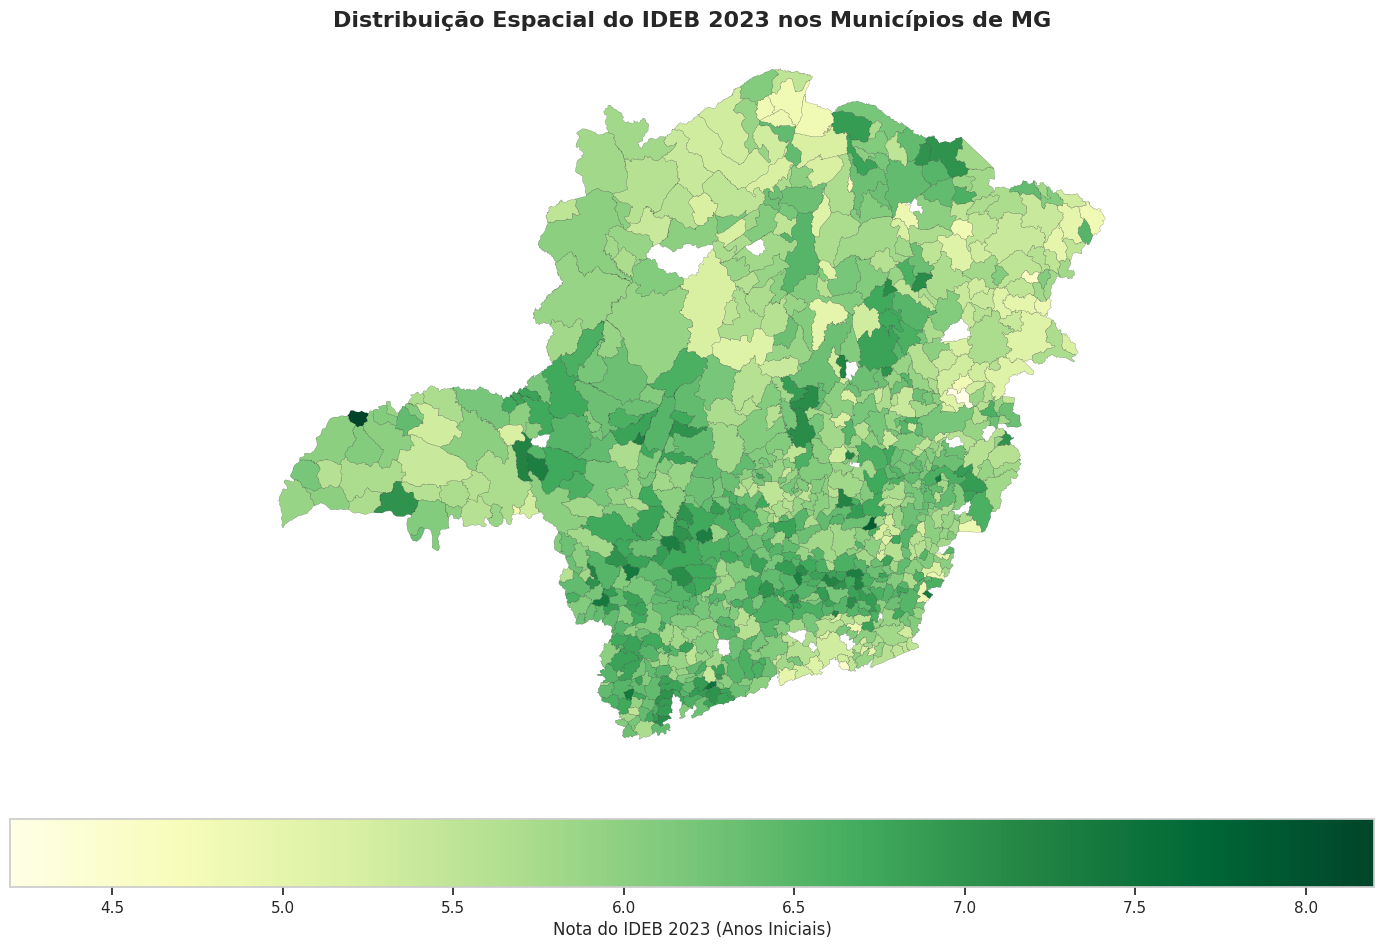

In [12]:
# Mapa coroplético: IDEB por município (gradiente de cor)

# Criando a janela do mapa
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

print("Gerando Mapa Coroplético do IDEB 2023...")

# Plota o mapa baseado na coluna de notas que limpamos
gdf_visualizacao.plot(
    column='nota_ideb_2023',
    cmap='YlGn',
    legend=True,
    legend_kwds={'label': "Nota do IDEB 2023 (Anos Iniciais)", 'orientation': "horizontal", 'pad': 0.05},
    ax=ax,
    edgecolor='black',
    linewidth=0.1
)

ax.set_title("Distribuição Espacial do IDEB 2023 nos Municípios de MG", fontsize=16, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

Gerando Gráfico de Dispersão com Linha de Tendência


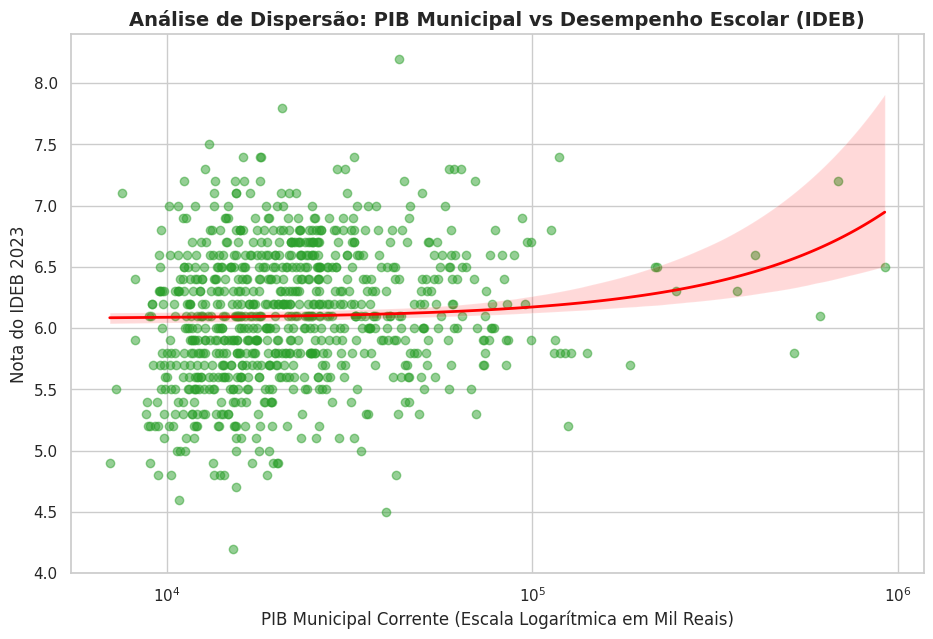

In [ ]:
# Scatter: renda × IDEB com linha de regressão

print("Gerando Gráfico de Dispersão com Linha de Tendência")

# Usar o regplot do Seaborn para desenhar a nuvem de pontos e a linha de regressão linear automaticamente
plt.figure(figsize=(11, 7))
sns.regplot(
    data=gdf_visualizacao,
    x='pib_total',
    y='nota_ideb_2023',
    scatter_kws={'alpha':0.5, 'color': '#2ca02c'},
    line_kws={'color': 'red', 'linewidth': 2}
)

# Como o PIB Bruto tem cidades com valores gigantescos, usamos escala logarítmica no eixo X
# para o gráfico não ficar esmagado no canto esquerdo
plt.xscale('log')

plt.title("Análise de Dispersão: PIB Municipal vs Desempenho Escolar (IDEB)", fontsize=14, fontweight='bold')
plt.xlabel("PIB Municipal Corrente (Escala Logarítmica em Mil Reais)", fontsize=12)
plt.ylabel("Nota do IDEB 2023", fontsize=12)

plt.show()

Calculando histórico para a Série Temporal


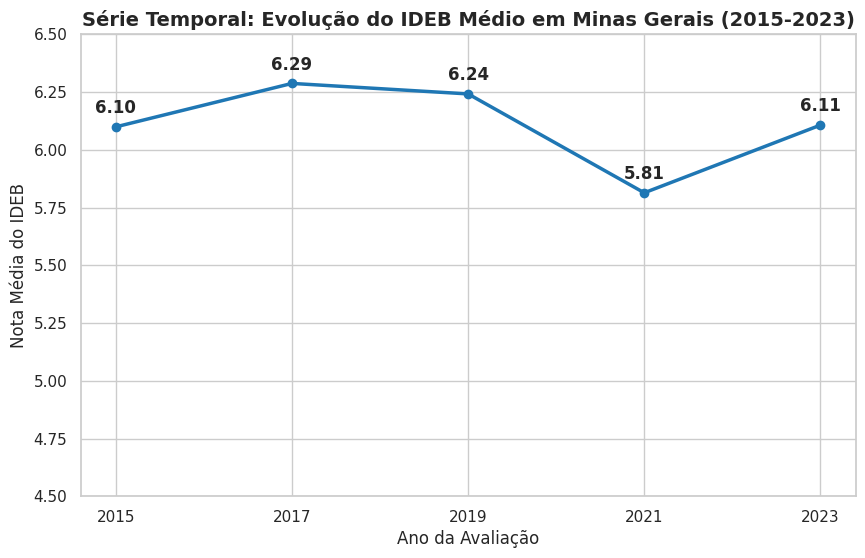

In [ ]:
#Série Temporal (Evolução do IDEB Médio 2015–2023)

print("Calculando histórico para a Série Temporal")

# Carregando a planilha original para capturar os anos anteriores
df_historico = pd.read_csv('dados/ideb_mg_anos_iniciais.csv', sep=';', encoding='utf-8')
df_hist_pub = df_historico[df_historico['Rede'] == 'Pública'].copy()

# Mapeamento das colunas de anos para analisar
anos = ['2015', '2017', '2019', '2021', '2023']
medias_anos = []

for ano in anos:
    nome_coluna = f'IDEB\n{ano}\n(N x P)'
    if nome_coluna not in df_hist_pub.columns and ano == '2021':
        nome_coluna = 'IDEB\n20212\n(N x P)'

    serie_num = pd.to_numeric(df_hist_pub[nome_coluna].astype(str).str.replace(',', '.'), errors='coerce')
    medias_anos.append(serie_num.mean())

# Plotando a linha do tempo
plt.figure(figsize=(10, 6))
plt.plot(anos, medias_anos, marker='o', linewidth=2.5, color='#1f77b4', label='Média Escolas Públicas')

plt.title("Série Temporal: Evolução do IDEB Médio em Minas Gerais (2015-2023)", fontsize=14, fontweight='bold')
plt.xlabel("Ano da Avaliação", fontsize=12)
plt.ylabel("Nota Média do IDEB", fontsize=12)
plt.ylim(4.5, 6.5)

for i, txt in enumerate(medias_anos):
    plt.annotate(f"{txt:.2f}", (anos[i], medias_anos[i]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.show()

Gerando Análise Regional de Metas


/tmp/ipykernel_5367/591990801.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


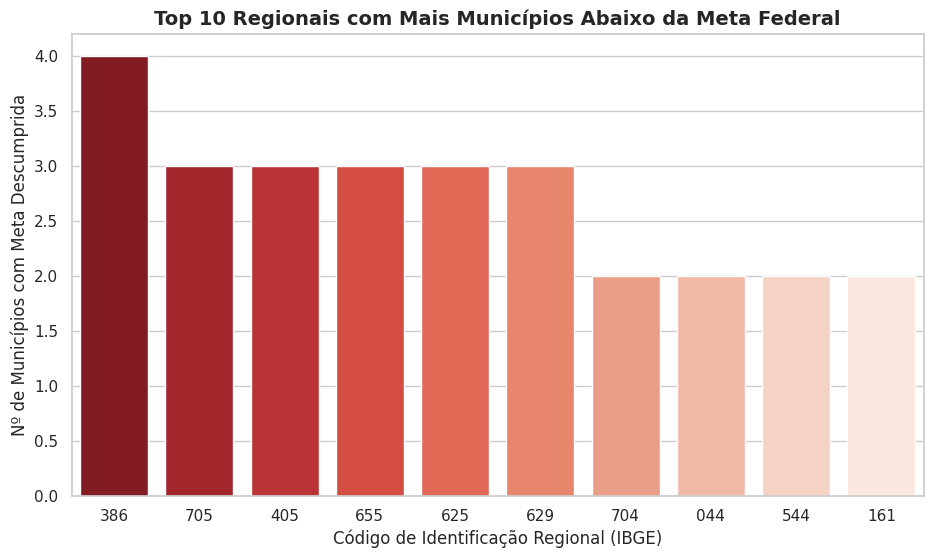

In [ ]:
# Gráfico de barras: municípios abaixo da meta por regional

print("Gerando Análise Regional de Metas")

# Lendo o arquivo
df_ideb_iniciais = pd.read_csv('dados/ideb_mg_anos_iniciais.csv', sep=';', encoding='utf-8')
df_ideb_publica_iniciais = df_ideb_iniciais[df_ideb_iniciais['Rede'] == 'Pública'].copy()

# Nomes das colunas mapeadas do INEP
coluna_ideb_23 = 'IDEB\n2023\n(N x P)'
coluna_meta_real = 'Unnamed: 121'

# Conversão numérica limpa
df_ideb_publica_iniciais['IDEB_2023_num'] = pd.to_numeric(df_ideb_publica_iniciais[coluna_ideb_23].astype(str).str.replace(',', '.'), errors='coerce')
df_ideb_publica_iniciais['META_2021_num'] = pd.to_numeric(df_ideb_publica_iniciais[coluna_meta_real].astype(str).str.replace(',', '.'), errors='coerce')

# Filtro de registros válidos descumpridores da meta
df_metas = df_ideb_publica_iniciais.dropna(subset=['IDEB_2023_num', 'META_2021_num']).copy()
df_abaixo = df_metas[df_metas['IDEB_2023_num'] < df_metas['META_2021_num']].copy()

# Extração da microregião baseada no prefixo do Código do Município do IBGE
df_abaixo['Regional_Cod'] = df_abaixo['Código do Município'].astype(str).str[2:5]

# Agrupamento das 10 regionais com maior índice de problemas
contagem_regional = df_abaixo['Regional_Cod'].value_counts().head(10).reset_index()
contagem_regional.columns = ['Regional (Código IBGE)', 'Quantidade de Municípios']

# Plotando o gráfico de barras vertical
plt.figure(figsize=(11, 6))
sns.barplot(
    data=contagem_regional,
    x='Regional (Código IBGE)',
    y='Quantidade de Municípios',
    palette='Reds_r'
)

plt.title("Top 10 Regionais com Mais Municípios Abaixo da Meta Federal", fontsize=14, fontweight='bold')
plt.xlabel("Código de Identificação Regional (IBGE)", fontsize=12)
plt.ylabel("Nº de Municípios com Meta Descumprida", fontsize=12)

plt.show()

Gerando o Heatmap Comparativo de Etapas por Regional


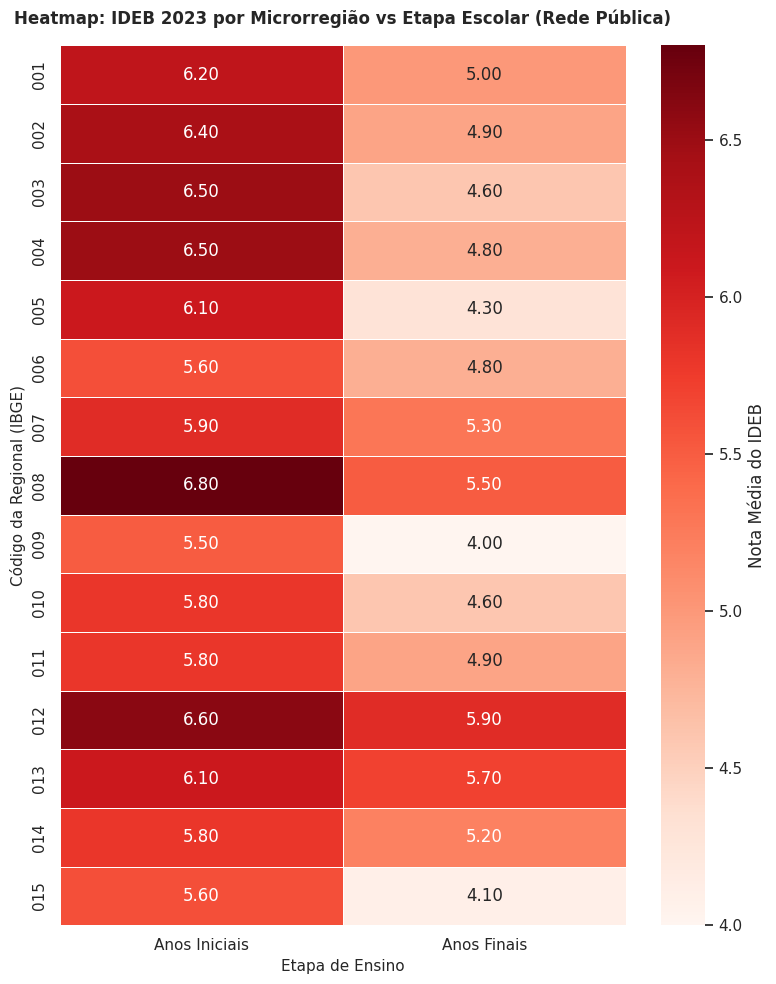

In [ ]:
# Heatmap: IDEB por microrregião × etapa escolar

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Gerando o Heatmap Comparativo de Etapas por Regional")

# Carregando e filtrando os dados dos Anos Iniciais
df_ini = pd.read_csv('dados/ideb_mg_anos_iniciais.csv', sep=';', encoding='utf-8')
df_ini_pub = df_ini[df_ini['Rede'] == 'Pública'].copy()
df_ini_pub['Anos Iniciais'] = pd.to_numeric(df_ini_pub['IDEB\n2023\n(N x P)'].astype(str).str.replace(',', '.'), errors='coerce')
df_ini_pub['Regional_Cod'] = df_ini_pub['Código do Município'].astype(str).str[2:5]

# Carregando e filtrando os dados dos Anos Finais
df_fin = pd.read_csv('dados/ideb_mg_anos_finais.csv', sep=';', encoding='utf-8')
df_fin_pub = df_fin[df_fin['Rede'] == 'Pública'].copy()
df_fin_pub['Anos Finais'] = pd.to_numeric(df_fin_pub['IDEB\n2023\n(N x P)'].astype(str).str.replace(',', '.'), errors='coerce')
df_fin_pub['Regional_Cod'] = df_fin_pub['Código do Município'].astype(str).str[2:5]

# Agrupando as médias por código regional para cada etapa
media_ini = df_ini_pub.groupby('Regional_Cod')['Anos Iniciais'].mean()
media_fin = df_fin_pub.groupby('Regional_Cod')['Anos Finais'].mean()

# Combinando as duas etapas em uma única matriz para o Heatmap
matriz_heatmap = pd.concat([media_ini, media_fin], axis=1).dropna().head(15)

# Desenhando o gráfico de matriz de calor (Heatmap)
plt.figure(figsize=(8, 10))
sns.heatmap(
    matriz_heatmap,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=0.5,
    cbar_kws={'label': 'Nota Média do IDEB'}
)

plt.title("Heatmap: IDEB 2023 por Microrregião vs Etapa Escolar (Rede Pública)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Etapa de Ensino", fontsize=11)
plt.ylabel("Código da Regional (IBGE)", fontsize=11)

plt.tight_layout()
plt.show()